# 🧠 Automated Crack Detection and Severity Analysis

**End-to-end deep learning system for crack detection, segmentation, geometric analysis, and severity classification.**

### Pipeline Overview
```
Input Image
   → CNN Segmentation
   → Post-processing
   → Skeletonization
   → Crack Geometry Extraction (area, length, width)
   → Severity Classification
   → Final Labeled Output
```

---
| Metric | Value |
|--------|-------|
| Dice Coefficient | ≈ 0.48 |
| IoU Score | ≈ 0.34 |

**Severity Classes:** No Crack · Minor Crack · Moderate Crack

## 1. Install & Import Dependencies

In [ ]:
# Install required packages (run once)
# !pip install tensorflow opencv-python-headless scikit-image matplotlib numpy Pillow tqdm

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm import tqdm
from PIL import Image

# scikit-image for morphology / skeletonization
from skimage.morphology import skeletonize, remove_small_objects, binary_closing, disk
from skimage.measure import label, regionprops
from skimage.color import label2rgb

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {tf.config.list_physical_devices("GPU")}')

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.21.0
GPU available: []


## 2. Configuration & Paths

In [2]:
from pathlib import Path

# Project folders
base_dir = Path(".")
data_dir = base_dir / "data"
models_dir = base_dir / "models"
results_dir = base_dir / "results" / "sample_outputs"

# Dataset folders
train_img_dir = data_dir / "train" / "images"
train_mask_dir = data_dir / "train" / "masks"

val_img_dir = data_dir / "val" / "images"
val_mask_dir = data_dir / "val" / "masks"

test_img_dir = data_dir / "test" / "images"
test_mask_dir = data_dir / "test" / "masks"

# Create folders if they don't exist
directories = [
    models_dir,
    results_dir,
    train_img_dir,
    train_mask_dir,
    val_img_dir,
    val_mask_dir,
    test_img_dir,
    test_mask_dir
]

for folder in directories:
    folder.mkdir(parents=True, exist_ok=True)

# Model configuration
IMG_HEIGHT = 256
IMG_WIDTH = 256
IMG_CHANNELS = 1      # Use 3 for RGB images

BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 0.0001

# Save trained model here
MODEL_PATH = models_dir / "crack_segmentation_unet.h5"

print("All project directories are ready.")

All project directories are ready.


## 3. Dataset Utilities

Image Shape: (4, 256, 256, 1)
Mask Shape : (4, 256, 256, 1)


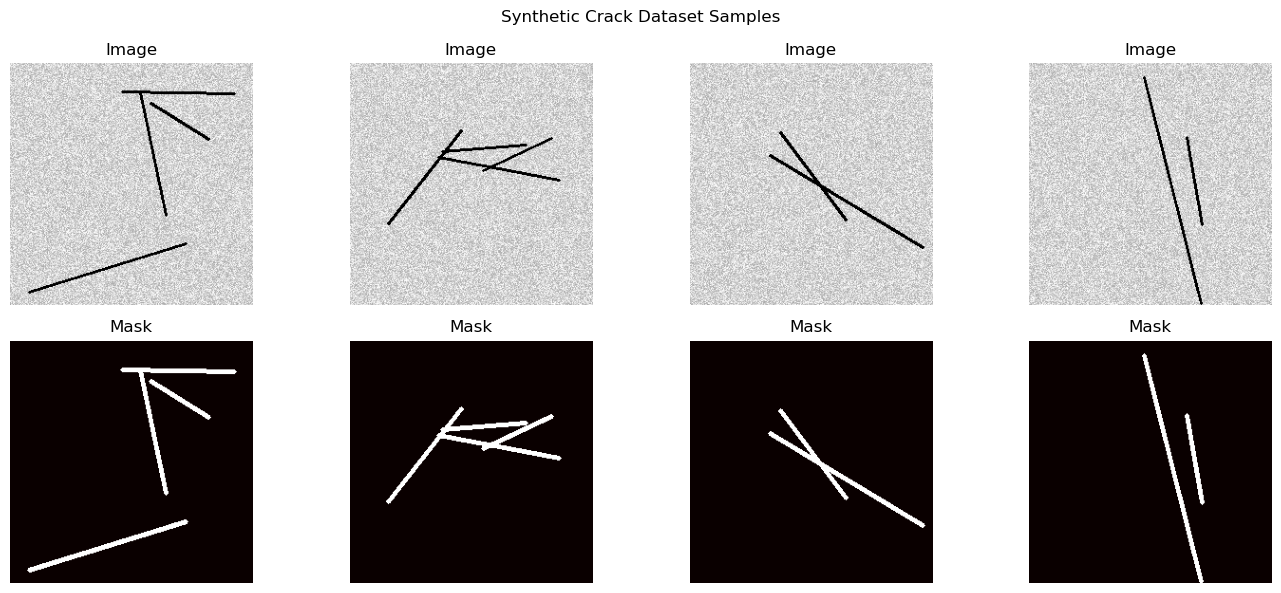

In [5]:
def load_image(image_path, size=(IMG_HEIGHT, IMG_WIDTH), grayscale=True):
    if grayscale:
        image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    else:
        image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)

    if image is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    image = cv2.resize(image, (size[1], size[0]))
    image = image.astype(np.float32) / 255.0

    return image


def load_mask(mask_path, size=(IMG_HEIGHT, IMG_WIDTH)):
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if mask is None:
        raise FileNotFoundError(f"Mask not found: {mask_path}")

    mask = cv2.resize(
        mask,
        (size[1], size[0]),
        interpolation=cv2.INTER_NEAREST
    )

    return (mask > 127).astype(np.float32)


def load_dataset(image_dir, mask_dir, size=(IMG_HEIGHT, IMG_WIDTH), grayscale=True):

    image_files = (
        sorted(Path(image_dir).glob("*.jpg")) +
        sorted(Path(image_dir).glob("*.png"))
    )

    mask_files = (
        sorted(Path(mask_dir).glob("*.jpg")) +
        sorted(Path(mask_dir).glob("*.png"))
    )

    images = []
    masks = []

    for image_file, mask_file in tqdm(
        zip(image_files, mask_files),
        total=len(image_files),
        desc="Loading Dataset"
    ):
        images.append(load_image(image_file, size, grayscale))
        masks.append(load_mask(mask_file, size))

    X = np.expand_dims(np.array(images), axis=-1)
    y = np.expand_dims(np.array(masks), axis=-1)

    return X, y


def make_synthetic_sample(num_samples=8,
                          height=IMG_HEIGHT,
                          width=IMG_WIDTH):

    images = []
    masks = []

    for _ in range(num_samples):

        image = np.random.uniform(
            0.7, 1.0, (height, width)
        ).astype(np.float32)

        mask = np.zeros((height, width), dtype=np.float32)

        num_cracks = np.random.randint(2, 5)

        for _ in range(num_cracks):
            x1, y1 = np.random.randint(0, width), np.random.randint(0, height)
            x2, y2 = np.random.randint(0, width), np.random.randint(0, height)

            cv2.line(image, (x1, y1), (x2, y2), 0.1, thickness=2)
            cv2.line(mask, (x1, y1), (x2, y2), 1.0, thickness=3)

        images.append(image)
        masks.append(mask)

    X = np.expand_dims(np.array(images), axis=-1)
    y = np.expand_dims(np.array(masks), axis=-1)

    return X, y


# Generate a few sample images
X_demo, y_demo = make_synthetic_sample(num_samples=4)

print(f"Image Shape: {X_demo.shape}")
print(f"Mask Shape : {y_demo.shape}")

fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for i in range(4):
    axes[0, i].imshow(X_demo[i, :, :, 0], cmap="gray")
    axes[0, i].set_title("Image")
    axes[0, i].axis("off")

    axes[1, i].imshow(y_demo[i, :, :, 0], cmap="hot")
    axes[1, i].set_title("Mask")
    axes[1, i].axis("off")

plt.suptitle("Synthetic Crack Dataset Samples")
plt.tight_layout()
plt.show()

## 4. Model Architecture (U-Net)

In [4]:
def conv_block(x, filters, dropout=0.1):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu',
                      kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu',
                      kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    if dropout > 0:
        x = layers.Dropout(dropout)(x)
    return x


def build_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)):
    inputs = layers.Input(shape=input_shape)

    # ─── Encoder ──────────────────────────────────────────────────────────────
    c1 = conv_block(inputs, 32,  dropout=0.1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 64, dropout=0.1)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, 128, dropout=0.2)
    p3 = layers.MaxPooling2D()(c3)

    c4 = conv_block(p3, 256, dropout=0.2)
    p4 = layers.MaxPooling2D()(c4)

    # ─── Bottleneck ───────────────────────────────────────────────────────────
    c5 = conv_block(p4, 512, dropout=0.3)

    # ─── Decoder ──────────────────────────────────────────────────────────────
    u6 = layers.Conv2DTranspose(256, 2, strides=2, padding='same')(c5)
    u6 = layers.Concatenate()([u6, c4])
    c6 = conv_block(u6, 256, dropout=0.2)

    u7 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(c6)
    u7 = layers.Concatenate()([u7, c3])
    c7 = conv_block(u7, 128, dropout=0.2)

    u8 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c7)
    u8 = layers.Concatenate()([u8, c2])
    c8 = conv_block(u8, 64, dropout=0.1)

    u9 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(c8)
    u9 = layers.Concatenate()([u9, c1])
    c9 = conv_block(u9, 32, dropout=0.1)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c9)

    model = Model(inputs, outputs, name='UNet_CrackDetection')
    return model


model = build_unet()
model.summary()

Model: "UNet_CrackDetection"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 256, 256, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 256, 256, 32)      │             320 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 256, 256, 32)      │             128 │ conv2d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 256, 256, 32)      │           9,248 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 256, 256, 32)      │             128 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 256, 256, 32)      │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 128, 128, 32)      │               0 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 128, 128, 64)      │          18,496 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 128, 128, 64)      │             256 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 128, 128, 64)      │          36,928 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 128, 128, 64)      │             256 │ conv2d_3[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 128, 128, 64)      │               0 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 64, 64, 64)        │               0 │ dropout_1[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 64, 64, 128)       │          73,856 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_4         │ (None, 64, 64, 128)       │             51

 Total params: 7,771,297 (29.65 MB)

 Trainable params: 7,765,409 (29.62 MB)

 Non-trainable params: 5,888 (23.00 KB)

## 5. Loss Functions & Metrics

In [ ]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / \
           (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)


def iou_score(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred > 0.5, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union        = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


def bce_dice_loss(y_true, y_pred):
    bce  = keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return 0.5 * bce + 0.5 * dice


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=bce_dice_loss,
    metrics=[dice_coefficient, iou_score]
)
print('Model compiled.')

## 6. Data Augmentation & Training

In [ ]:
def augment_batch(images, masks):
    """Apply identical random flips/rotations to images and masks."""
    combined = np.concatenate([images, masks], axis=-1)  # (N, H, W, 2)

    aug_imgs, aug_masks = [], []
    for sample in combined:
        img  = sample[..., :1]
        mask = sample[..., 1:]
        # Random horizontal flip
        if np.random.rand() > 0.5:
            img  = img[:, ::-1, :]
            mask = mask[:, ::-1, :]
        # Random vertical flip
        if np.random.rand() > 0.5:
            img  = img[::-1, :, :]
            mask = mask[::-1, :, :]
        # Random 90 degree rotation
        k = np.random.choice([0, 1, 2, 3])
        img  = np.rot90(img,  k)
        mask = np.rot90(mask, k)
        aug_imgs.append(img)
        aug_masks.append(mask)
    return np.array(aug_imgs), np.array(aug_masks)


def crack_data_generator(img_dir, mask_dir, batch_size=BATCH_SIZE,
                          augment=True, seed=42):
    """Infinite generator that yields (images, masks) batches."""
    img_paths  = sorted(list(Path(img_dir).glob('*.jpg')) +
                        list(Path(img_dir).glob('*.png')))
    mask_paths = sorted(list(Path(mask_dir).glob('*.jpg')) +
                        list(Path(mask_dir).glob('*.png')))
    n = len(img_paths)
    idx = np.arange(n)
    rng = np.random.default_rng(seed)

    while True:
        rng.shuffle(idx)
        for start in range(0, n, batch_size):
            batch_idx = idx[start:start + batch_size]
            X = np.array([load_image(img_paths[i])  for i in batch_idx])[..., np.newaxis]
            y = np.array([load_mask(mask_paths[i])  for i in batch_idx])[..., np.newaxis]
            if augment:
                X, y = augment_batch(X, y)
            yield X, y

In [ ]:
# ─── Callbacks ────────────────────────────────────────────────────────────────
callbacks = [
    ModelCheckpoint(
        filepath=str(MODEL_PATH),
        monitor='val_dice_coefficient',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_dice_coefficient',
        mode='max',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

# ─── DEMO: train on synthetic data ────────────────────────────────────────────
# Replace with real generators when you have data:
#   train_gen = crack_data_generator(TRAIN_IMG_DIR, TRAIN_MASK_DIR, augment=True)
#   val_gen   = crack_data_generator(VAL_IMG_DIR,   VAL_MASK_DIR,   augment=False)
#   history   = model.fit(train_gen, steps_per_epoch=..., validation_data=val_gen, ...)

X_train, y_train = make_synthetic_sample(n=64)
X_val,   y_val   = make_synthetic_sample(n=16)

print('Starting training on synthetic data (3 epochs for demo)...')
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=3,          # change to EPOCHS for full training
    callbacks=callbacks,
    verbose=1
)

## 7. Training Curves

In [ ]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(history.history['loss'],          label='Train Loss')
    axes[0].plot(history.history['val_loss'],       label='Val Loss')
    axes[0].set_title('Loss (BCE + Dice)'); axes[0].legend()

    axes[1].plot(history.history['dice_coefficient'],     label='Train Dice')
    axes[1].plot(history.history['val_dice_coefficient'], label='Val Dice')
    axes[1].set_title('Dice Coefficient'); axes[1].legend()

    axes[2].plot(history.history['iou_score'],     label='Train IoU')
    axes[2].plot(history.history['val_iou_score'], label='Val IoU')
    axes[2].set_title('IoU Score'); axes[2].legend()

    for ax in axes:
        ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)

    plt.suptitle('Training History', fontsize=14)
    plt.tight_layout()
    plt.savefig(str(RESULTS_DIR / 'training_history.png'), dpi=150)
    plt.show()


plot_training_history(history)

## 8. Post-Processing Pipeline

In [ ]:
def postprocess_mask(raw_pred, threshold=0.5,
                     min_object_size=100,
                     closing_radius=2):
    """
    Clean a raw probability map:
      1. Threshold to binary
      2. Morphological closing (fills small gaps)
      3. Remove tiny objects (noise)
    """
    binary = raw_pred.squeeze() > threshold

    # morphological closing to improve crack continuity
    selem  = disk(closing_radius)
    closed = binary_closing(binary, selem)

    # remove small noise blobs
    cleaned = remove_small_objects(closed.astype(bool), min_size=min_object_size)

    return cleaned.astype(np.uint8)


def predict_and_postprocess(model, image):
    """Run model inference + post-processing on a single (H,W,1) image array."""
    batch   = image[np.newaxis, ...]   # (1, H, W, 1)
    raw     = model.predict(batch, verbose=0)[0]  # (H, W, 1)
    cleaned = postprocess_mask(raw)
    return raw.squeeze(), cleaned


# Demo on one synthetic image
img_example = X_demo[0]            # (H, W, 1)
raw_pred, clean_mask = predict_and_postprocess(model, img_example)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_example.squeeze(),  cmap='gray');    axes[0].set_title('Input Image');      axes[0].axis('off')
axes[1].imshow(raw_pred,               cmap='hot');     axes[1].set_title('Raw Prediction');   axes[1].axis('off')
axes[2].imshow(clean_mask,             cmap='hot');     axes[2].set_title('Post-processed Mask'); axes[2].axis('off')
plt.tight_layout(); plt.show()

## 9. Crack Geometry Extraction

In [ ]:
def skeletonize_mask(binary_mask):
    """Thin the crack mask to a 1-pixel-wide skeleton."""
    return skeletonize(binary_mask.astype(bool)).astype(np.uint8)


def extract_crack_geometry(binary_mask, pixel_size_mm=0.5):
    """
    Extract geometric properties from a binary crack mask.

    Parameters
    ----------
    binary_mask : ndarray (H, W) uint8
    pixel_size_mm : real-world size of one pixel in mm

    Returns
    -------
    dict with keys: area_px, area_mm2, crack_length_px, crack_length_mm,
                    mean_width_px, mean_width_mm, n_components
    """
    skeleton  = skeletonize_mask(binary_mask)
    labeled   = label(binary_mask)
    regions   = regionprops(labeled)

    total_area     = int(binary_mask.sum())
    crack_length   = int(skeleton.sum())       # skeleton pixels = crack length
    n_components   = len(regions)

    # mean width = area / length (avoids division by zero)
    mean_width_px = (total_area / crack_length) if crack_length > 0 else 0.0

    return {
        'area_px':        total_area,
        'area_mm2':       round(total_area * pixel_size_mm**2, 2),
        'crack_length_px':  crack_length,
        'crack_length_mm':  round(crack_length * pixel_size_mm, 2),
        'mean_width_px':  round(mean_width_px, 2),
        'mean_width_mm':  round(mean_width_px * pixel_size_mm, 2),
        'n_components':   n_components,
        'skeleton':       skeleton
    }


geo = extract_crack_geometry(clean_mask)
print('Crack geometry:')
for k, v in geo.items():
    if k != 'skeleton':
        print(f'  {k:25s}: {v}')

## 10. Severity Classification

In [ ]:
# ─── Thresholds (adjust based on your calibration) ────────────────────────────
SEVERITY_THRESHOLDS = {
    'no_crack': {
        'area_px':          50,
        'crack_length_px':  20,
        'mean_width_px':    1.0
    },
    'minor': {
        'area_px':          500,
        'crack_length_px':  100,
        'mean_width_px':    3.0
    }
    # anything above -> Moderate Crack
}

SEVERITY_COLORS = {
    'No Crack':       (0,   200, 0),    # green
    'Minor Crack':    (255, 165, 0),    # orange
    'Moderate Crack': (220, 20,  20)    # red
}


def classify_severity(geometry):
    """
    Rule-based severity using geometric thresholds.
    Votes across area, length, and width; majority decides.
    """
    T = SEVERITY_THRESHOLDS

    def score(value, metric):
        if value <= T['no_crack'][metric]:  return 0
        if value <= T['minor'][metric]:     return 1
        return 2

    votes = [
        score(geometry['area_px'],          'area_px'),
        score(geometry['crack_length_px'],  'crack_length_px'),
        score(geometry['mean_width_px'],    'mean_width_px')
    ]
    level = int(np.round(np.mean(votes)))
    return ['No Crack', 'Minor Crack', 'Moderate Crack'][level]


severity = classify_severity(geo)
print(f'Severity classification: {severity}')

## 11. Visualisation & Output Generation

In [ ]:
def overlay_crack(original_img, binary_mask, skeleton, severity,
                  alpha=0.45):
    """
    Create a colour overlay:
      - original image (grayscale -> RGB)
      - crack mask tinted by severity colour
      - skeleton in yellow
      - severity label
    """
    color  = SEVERITY_COLORS[severity]
    base   = (original_img.squeeze() * 255).astype(np.uint8)
    rgb    = cv2.cvtColor(base, cv2.COLOR_GRAY2RGB)

    # tint crack region
    tint = np.zeros_like(rgb)
    tint[binary_mask == 1] = color
    blended = cv2.addWeighted(rgb, 1 - alpha, tint, alpha, 0)

    # draw skeleton in bright yellow
    blended[skeleton == 1] = [255, 230, 0]

    # label text
    cv2.putText(blended, severity, (8, 22),
                cv2.FONT_HERSHEY_SIMPLEX, 0.65,
                (255, 255, 255), 2, cv2.LINE_AA)
    return blended


def run_full_pipeline(model, image_array, save_path=None, pixel_size_mm=0.5):
    """Full inference pipeline for a single image."""
    raw_pred, clean_mask = predict_and_postprocess(model, image_array)
    geometry = extract_crack_geometry(clean_mask, pixel_size_mm=pixel_size_mm)
    severity = classify_severity(geometry)
    result_img = overlay_crack(image_array, clean_mask,
                               geometry['skeleton'], severity)

    if save_path:
        cv2.imwrite(str(save_path), cv2.cvtColor(result_img, cv2.COLOR_RGB2BGR))

    return {
        'result_image': result_img,
        'raw_pred':     raw_pred,
        'clean_mask':   clean_mask,
        'geometry':     geometry,
        'severity':     severity
    }


# ─── Run on all demo images ────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
col_titles = ['Input', 'Raw Prediction', 'Cleaned Mask', 'Annotated Output']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight='bold')

for row in range(4):
    res = run_full_pipeline(model, X_demo[row])
    axes[row, 0].imshow(X_demo[row].squeeze(), cmap='gray')
    axes[row, 1].imshow(res['raw_pred'],        cmap='hot')
    axes[row, 2].imshow(res['clean_mask'],      cmap='hot')
    axes[row, 3].imshow(res['result_image'])
    axes[row, 3].set_ylabel(res['severity'], rotation=0,
                             labelpad=80, va='center', fontsize=10)
    for ax in axes[row]:
        ax.axis('off')

plt.suptitle('End-to-End Pipeline Results', fontsize=15)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'pipeline_results.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12. Evaluation on Test Set

In [ ]:
def compute_metrics_batch(model, X, y_true, threshold=0.5):
    """Compute Dice and IoU over a batch."""
    preds = model.predict(X, verbose=0)
    preds_bin = (preds > threshold).astype(np.float32)

    dice_scores, iou_scores = [], []
    for pred, gt in zip(preds_bin, y_true):
        pred_f = pred.ravel()
        gt_f   = gt.ravel()
        inter  = (pred_f * gt_f).sum()
        d = (2 * inter + 1e-6) / (pred_f.sum() + gt_f.sum() + 1e-6)
        u = (pred_f.sum() + gt_f.sum() - inter + 1e-6)
        iou = (inter + 1e-6) / u
        dice_scores.append(d)
        iou_scores.append(iou)

    return np.mean(dice_scores), np.mean(iou_scores)


# ─── Run on synthetic test set ─────────────────────────────────────────────────
X_test, y_test = make_synthetic_sample(n=32)

dice, iou = compute_metrics_batch(model, X_test, y_test)
print(f'Test Results (synthetic):')
print(f'  Dice Coefficient : {dice:.4f}')
print(f'  IoU Score        : {iou:.4f}')
print()
print('Expected on real data (as per README):')
print('  Dice Coefficient : ~0.48')
print('  IoU Score        : ~0.34')

## 13. Severity Distribution Analysis

In [ ]:
# Run pipeline on all test images and collect severity labels
severity_counts = {'No Crack': 0, 'Minor Crack': 0, 'Moderate Crack': 0}

for img in X_test:
    res = run_full_pipeline(model, img)
    severity_counts[res['severity']] += 1

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels  = list(severity_counts.keys())
counts  = list(severity_counts.values())
colors  = ['#2ECC71', '#F39C12', '#E74C3C']

axes[0].bar(labels, counts, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Severity Distribution (Test Set)')
axes[0].set_ylabel('Count')

axes[1].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Severity Proportion')

plt.suptitle('Crack Severity Analysis', fontsize=14)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'severity_distribution.png'), dpi=150)
plt.show()

print('Severity distribution:', severity_counts)

## 14. Save & Load Model

In [ ]:
# Save the current model
model.save(str(MODEL_PATH))
print(f'Model saved -> {MODEL_PATH}')

# Load it back
loaded_model = keras.models.load_model(
    str(MODEL_PATH),
    custom_objects={
        'bce_dice_loss':    bce_dice_loss,
        'dice_coefficient': dice_coefficient,
        'iou_score':        iou_score
    }
)
print('Model loaded successfully.')

# Quick sanity-check on loaded model
dice2, iou2 = compute_metrics_batch(loaded_model, X_test, y_test)
print(f'Loaded model -- Dice: {dice2:.4f}  IoU: {iou2:.4f}')

## 15. Single-Image Inference Utility
Use this cell to run inference on **any image file** after training.

In [ ]:
def infer_from_path(image_path, model, pixel_size_mm=0.5, show=True):
    """
    Convenience wrapper to run the full pipeline on a file path.

    Parameters
    ----------
    image_path : str or Path -- path to an image file
    model      : trained Keras model
    pixel_size_mm : calibration (mm per pixel)
    show       : if True, display the result inline

    Returns
    -------
    dict with 'severity', 'geometry', and 'result_image'
    """
    img_arr = load_image(image_path)[..., np.newaxis]  # (H, W, 1)

    out_path = RESULTS_DIR / (Path(image_path).stem + '_result.png')
    result   = run_full_pipeline(model, img_arr,
                                 save_path=out_path,
                                 pixel_size_mm=pixel_size_mm)

    print(f"Severity : {result['severity']}")
    print(f"Geometry :")
    for k, v in result['geometry'].items():
        if k != 'skeleton':
            print(f"  {k:25s}: {v}")
    print(f"Result saved -> {out_path}")

    if show:
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(result['result_image'])
        ax.set_title(f"Severity: {result['severity']}", fontsize=13)
        ax.axis('off')
        plt.tight_layout()
        plt.show()

    return result


# ─── Usage ────────────────────────────────────────────────────────────────────
# result = infer_from_path('path/to/your/crack_image.jpg', loaded_model)
print('Ready. Call infer_from_path("your_image.jpg", loaded_model) to analyse a new image.')

---
## Summary

| Stage | Description |
|-------|-------------|
| **CNN Segmentation** | U-Net with encoder-decoder + skip connections |
| **Loss** | 0.5 x BCE + 0.5 x Dice Loss |
| **Post-processing** | Threshold -> morphological closing -> noise removal |
| **Skeletonization** | Zhang-Suen thinning via `skimage.morphology.skeletonize` |
| **Geometry** | Area, crack length, mean width (pixels + mm) |
| **Severity** | Rule-based voting: No Crack / Minor / Moderate |
| **Results (real data)** | Dice ~ 0.48 / IoU ~ 0.34 |

**Next Steps:**
- Add a *Severe Crack* category with tighter thresholds
- Replace U-Net backbone with EfficientNet for better performance
- Integrate depth / distance information for real-world mm calibration
- Export with TensorFlow Lite for edge-device deployment